# Исследование тарифов Мегалайна

<h1>Содержание<span class="tocSkip"></span></h1>

<div class="toc"><ul class="toc-item">
    <li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li>
    <li><span><a href="#Изучение-данных-из-файлов" data-toc-modified-id="Изучение-данных-из-файлов-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Изучение данных из файлов</a></span></li>
    <li><span><a href="#Расчёт-показателей" data-toc-modified-id="Расчёт-показателей-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Расчёт показателей</a></span></li>
    <li><span><a href="#Анализ-данных" data-toc-modified-id="Анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Анализ данных</a></span></li>
    <li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Проверка гипотез</a></span></li></ul></div>

## Описание проекта

«Мегалайн» — федерального оператора сотовой связи, предлагает клиентам два тарифных плана: «Смарт» и «Ультра». Чтобы скорректировать рекламный бюджет, коммерческий департамент хочет понять, какой тариф приносит больше денег.

Нужно сделать предварительный анализ тарифов на небольшой выборке клиентов. В нашем распоряжении данные 500 пользователей «Мегалайна»: кто они, откуда, каким тарифом пользуются, сколько звонков и сообщений каждый отправил за 2018 год. Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.

**Описание тарифов**

**Тариф «Смарт»**

1. Ежемесячная плата: 550 рублей
2. Включено 500 минут разговора, 50 сообщений и 15 Гб интернет-трафика
3. Стоимость услуг сверх тарифного пакета:
    - минута разговора: 3 рубля
    - сообщение: 3 рубля
    - 1 Гб интернет-трафика: 200 рублей
        
**Тариф «Ультра»**

1. Ежемесячная плата: 1950 рублей
2. Включено 3000 минут разговора, 1000 сообщений и 30 Гб интернет-трафика
3. Стоимость услуг сверх тарифного пакета:
    - минута разговора: 1 рубль
    - сообщение: 1 рубль
    - 1 Гб интернет-трафика: 150 рублей

**Примечание**

«Мегалайн» всегда округляет секунды до минут, а мегабайты — до гигабайт. Каждый звонок округляется отдельно: даже если он длился всего 1 секунду, будет засчитан как 1 минута.

Для веб-трафика отдельные сессии не считаются. Вместо этого общая сумма за месяц округляется в бо́льшую сторону. Если абонент использует 1025 мегабайт в этом месяце, с него возьмут плату за 2 гигабайта. Примите, что неиспользованные за предыдущий месяц звонки, смс, интернет на следующий месяц не переносятся.

## Изучение данных из файлов

In [103]:
# импорт библиотек
import pandas as pd
import numpy as np
import math
from scipy import stats as st
import matplotlib.pyplot as plt

In [3]:
df_calls = pd.read_csv('data/calls.csv')

In [4]:
df_internet = pd.read_csv('data/internet.csv')

In [5]:
df_messages = pd.read_csv('data/messages.csv')

In [6]:
df_tariffs = pd.read_csv('data/tariffs.csv')

In [7]:
df_users = pd.read_csv('data/users.csv')

### Описание данных в таблице df_users

In [8]:
# Проверяем тип столбцов 
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


**Таблица users (информация о пользователях):**

- user_id — уникальный идентификатор пользователя
- first_name — имя пользователя
- last_name — фамилия пользователя
- age — возраст пользователя (годы)
- reg_date — дата подключения тарифа (день, месяц, год)
- churn_date — дата прекращения пользования тарифом (если значение пропущено, то тариф ещё действовал на момент выгрузки данных)
- city — город проживания пользователя
- tariff — название тарифного плана

Мы видим что только у 38 пользователей была дата прекращения пользования тарифом, а у остальных тариф ещё действовал на момент выгрузки данных.

In [9]:
# Выводим на экран первые пять строк таблицы
df_users.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


Нужно поменять тип столбцов `churn_date` и `reg_date` на `datetime`.

In [10]:
# Меняем тип столбцов churn_date и reg_date на datetime
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])

In [11]:
# Проверяем тип столбцов 
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   age         500 non-null    int64         
 2   churn_date  38 non-null     datetime64[ns]
 3   city        500 non-null    object        
 4   first_name  500 non-null    object        
 5   last_name   500 non-null    object        
 6   reg_date    500 non-null    datetime64[ns]
 7   tariff      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


Имеется 8 столбцов в таблице `df_users`. 4 из них имеет тип `object`, 2 из них имеет тип `int64`, 2 из них имеет тип `datetime64[ns]`.

In [12]:
# Проверка сколько уникальных пользователей
df_users['user_id'].nunique()

500

Результат показывает что все 500 пользователей уникальны. Также важно что ни один пользователь не сменял тарифы в периоде выгрузки данных, если сменял бы то уникальные пользователи повторялись бы. 

In [13]:
df_users.describe()

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


В средний возраст пользователя 46 лет.  Минимальное значение возраста 18 лет, максимальное значение возраста 75 лет. 75% пользователей младше 62 года.

In [14]:
# Проверяем период выгрузки
min_date = df_users['reg_date'].min()
max_date = df_users['reg_date'].max()
print('Выгрузка данных с {} до {}'.format(min_date, max_date))

Выгрузка данных с 2018-01-01 00:00:00 до 2018-12-31 00:00:00


### Описание данных в таблице df_calls

In [15]:
# Проверяем тип столбцов 
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB


**Таблица calls (информация о звонках):**

- id — уникальный номер звонка
- call_date — дата звонка
- duration — длительность звонка в минутах
- user_id — идентификатор пользователя, сделавшего звонок

Мы видим что в таблице `df_calls` пустых данных нету.

In [16]:
# Выводим на экран первые пять строк таблицы
df_calls.head(5)

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


Нужно поменять тип столбца `call_date` на `datetime`.

In [17]:
# Меняем тип столбца call_date на datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

In [18]:
# Провереям тип столбцов 
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         202607 non-null  object        
 1   call_date  202607 non-null  datetime64[ns]
 2   duration   202607 non-null  float64       
 3   user_id    202607 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.2+ MB


Имеется 4 столбца в таблице `df_calls`. 1 из них имеет тип `object`, 1 из них имеет тип `int64`, 1 из них имеет тип `datetime64[ns]`, 1 из них имеет тип `float64`.

In [19]:
# Выводим на экран количество уникальных пользователей
df_calls['user_id'].nunique()

492

Результат показывает что всего 492 уникальных пользователей.

In [20]:
# Выводим на экран количество уникальных id звонков
df_calls['id'].nunique()

202607

`id` всех звонков уникальны.

In [21]:
df_calls.describe()

,duration,user_id
count,202607.000000,202607.000000
mean,6.755887,1253.940619
std,5.843365,144.722751
min,0.000000,1000.000000
25%,1.300000,1126.000000
50%,6.000000,1260.000000
75%,10.700000,1379.000000
max,38.000000,1499.000000


Средняя продолжительность каждого звонка составляет 7 минут. Минимальное значение звонка 0 минут, максимальное значение 38 минут. 75% продолжительность каждого звонка составляет до 10 минут.

In [22]:
# Проверяем период выгрузки
min_date = df_calls['call_date'].min()
max_date = df_calls['call_date'].max()
print('Выгрузка данных с {} до {}'.format(min_date, max_date))

Выгрузка данных с 2018-01-01 00:00:00 до 2018-12-31 00:00:00


### Описание данных в таблице df_messages

In [23]:
# Проверяем тип столбцов 
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            123036 non-null  object
 1   message_date  123036 non-null  object
 2   user_id       123036 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.8+ MB


**Таблица messages (информация о сообщениях):**

- id — уникальный номер сообщения
- message_date — дата сообщения
- user_id — идентификатор пользователя, отправившего сообщение

Мы видим что в таблице df_messages пустых данных нету.

In [24]:
# Выводим на экран первые пять строк таблицы
df_messages.head(5)

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


Нужно поменять тип столбца `message_date` на `datetime`.

In [25]:
# Меняем столбец message_date на datetime
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

In [26]:
# Проверяем тип столбцов 
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            123036 non-null  object        
 1   message_date  123036 non-null  datetime64[ns]
 2   user_id       123036 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


3 столбца в таблице `df_messages`. 1 из них имеет тип `object`, 1 из них имеет тип `int64`, 1 из них имеет тип `datetime64[ns]`.

In [27]:
# Проверим сколько уникальных пользователей
df_messages['user_id'].nunique()

426

Результат показывает что в таблице `df_messages` всего 426 уникальных пользователей.

In [28]:
# Выводим на экран количество уникальных id сообщений
df_messages['id'].nunique()

123036

`id` всех сообщений уникальны.

In [29]:
# Проверяем период выгрузки
min_date = df_messages['message_date'].min()
max_date = df_messages['message_date'].max()
print('Выгрузка данных с {} до {}'.format(min_date, max_date))

Выгрузка данных с 2018-01-02 00:00:00 до 2018-12-31 00:00:00


### Описание данных в таблице df_internet

In [30]:
# Проверяем тип столбцов 
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  object 
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  object 
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB


**Таблица internet (информация об интернет-сессиях):**

- id — уникальный номер сессии
- mb_used — объём потраченного за сессию интернет-трафика (в мегабайтах)
- session_date — дата интернет-сессии
- user_id — идентификатор пользователя

Мы видим что в таблице `df_internet` пустых данных нету.

In [31]:
# Выводим на экран первые пять строк таблицы
df_internet.head(5)

,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


Нужно поменять тип столбца `session_date` на `datetime`.

In [32]:
# Меняем столбец message_date на datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

In [33]:
# Удалеям столбец Unnamed: 0
df_internet.drop('Unnamed: 0', axis=1, inplace=True)

Удалили столбец `Unnamed: 0` так как значения повторяются с индексом таблицы.

In [34]:
# Проверяем тип столбцов 
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            149396 non-null  object        
 1   mb_used       149396 non-null  float64       
 2   session_date  149396 non-null  datetime64[ns]
 3   user_id       149396 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.6+ MB


4 столбца в таблице `df_internet`. 1 из них имеет тип `object`, 1 из них имеет тип `int64`, 1 из них имеет тип `datetime64[ns]`, 1 из них имеет тип `float64`.

In [35]:
# Проверка сколько уникальных пользователей
df_internet['user_id'].nunique()

497

Результат показывает в таблице `df_internet` всего 497 уникальных пользователей.

In [36]:
# Выводим на экран количество уникальных id звонков
df_internet['id'].nunique()

149396

`id` всех интернет уникальны.

In [37]:
df_internet.describe()

,mb_used,user_id
count,149396.000000,149396.000000
mean,370.192426,1252.099842
std,278.300951,144.050823
min,0.000000,1000.000000
25%,138.187500,1130.000000
50%,348.015000,1251.000000
75%,559.552500,1380.000000
max,1724.830000,1499.000000


В среднем пользователи используют 370 MB интернета.  Минимальное значение 0 MB, максимальное значение 1724 MB за одну сессию. 75% пользователей использует до 560 MB за одну сессию.

In [38]:
# Проверяем период выгрузки
min_date = df_internet['session_date'].min()
max_date = df_internet['session_date'].max()
print('Выгрузка данных с {} до {}'.format(min_date, max_date))

Выгрузка данных с 2018-01-01 00:00:00 до 2018-12-31 00:00:00


### Описание данных в таблице df_tariffs

In [39]:
# Проверяем тип столбцов 
df_tariffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 256.0+ bytes


**Таблица tariffs (информация о тарифах):**

- tariff_name — название тарифа
- rub_monthly_fee — ежемесячная абонентская плата в рублях
- minutes_included — количество минут разговора в месяц, включённых в абонентскую плату
- messages_included — количество сообщений в месяц, включённых в абонентскую плату
- mb_per_month_included — объём интернет-трафика, включённого в абонентскую плату (в мегабайтах)
- rub_per_minute — стоимость минуты разговора сверх тарифного пакета (например, если в тарифе 100 минут разговора в месяц, то со 101 минуты будет взиматься плата)
- rub_per_message — стоимость отправки сообщения сверх тарифного пакета
- rub_per_gb — стоимость дополнительного гигабайта интернет-трафика сверх тарифного пакета (1 гигабайт = 1024 мегабайта)

В таблице `df_tariffs` пустых данных нету. 8 столбцов в таблице df_tariffs. 7 из них имеет тип `int64`, 1 из них имеет тип `object`.

In [40]:
# Выводим на экран таблицу
df_tariffs.head()

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


⚡ **Вывод:**
- Были изменены столбцы с данными даты.
- В данных нету пустых строк.
- Распределение данных является ожидаемым, ошибки в данных не найдены.

<span><a href="#Содержание" data-toc-modified-id="Содержание"><span class="toc-item-num"></span>Содержание</a></span>

## Расчёт показателей

**- Посчитаем для каждого пользователя количество сделанных звонков и израсходованных минут разговора по месяцам**

In [41]:
# Округляем продолжительность звонков
df_calls['duration_rounded'] = np.ceil(df_calls['duration'])

In [42]:
# Создаем столбец month
df_calls['month'] = df_calls['call_date'].astype('datetime64[M]')

In [43]:
# Проверяем округлённые цифры по продолжительности звонков и столбец month
df_calls.head(5)

,id,call_date,duration,user_id,duration_rounded,month
0,1000_0,2018-07-25,0.00,1000,0.0,2018-07-01
1,1000_1,2018-08-17,0.00,1000,0.0,2018-08-01
2,1000_2,2018-06-11,2.85,1000,3.0,2018-06-01
3,1000_3,2018-09-21,13.80,1000,14.0,2018-09-01
4,1000_4,2018-12-15,5.18,1000,6.0,2018-12-01


In [44]:
# Находим количество сделанных звонков и израсходованных минут разговора по месяцам
vol_calls = df_calls.pivot_table(index=['user_id', 'month'], values=['duration_rounded'], aggfunc=['count', 'sum'])
vol_calls

count              sum
                   duration_rounded duration_rounded
user_id month                                       
1000    2018-05-01               22            159.0
        2018-06-01               43            172.0
        2018-07-01               47            340.0
        2018-08-01               52            408.0
        2018-09-01               58            466.0
...                             ...              ...
1498    2018-10-01               41            247.0
1499    2018-09-01                9             70.0
        2018-10-01               68            449.0
        2018-11-01               74            612.0
        2018-12-01               69            492.0

[3174 rows x 2 columns]

**- Посчитаем для каждого пользователя количество отправленных сообщений по месяцам**

In [45]:
# Создаем столбец month
df_messages['month'] = df_messages['message_date'].astype('datetime64[M]')

In [46]:
# Находим количество отправленных сообщений по месяцам 
vol_messages = df_messages.pivot_table(index=['user_id', 'month'], values=['id'], aggfunc=['count'])
vol_messages

count
                      id
user_id month           
1000    2018-05-01    22
        2018-06-01    60
        2018-07-01    75
        2018-08-01    81
        2018-09-01    57
...                  ...
1498    2018-10-01    42
1499    2018-09-01    11
        2018-10-01    48
        2018-11-01    59
        2018-12-01    66

[2717 rows x 1 columns]

**- Посчитаем для каждого пользователя объем израсходованного интернет-трафика по месяцам**

In [47]:
# Создаем столбец month
df_internet['month'] = df_internet['session_date'].astype('datetime64[M]')

In [48]:
# Находим объем израсходованного интернет-трафика по месяцам
vol_internet = df_internet.pivot_table(index=['user_id', 'month'], values=['mb_used'], aggfunc=['sum'])
vol_internet

sum
                     mb_used
user_id month               
1000    2018-05-01   2253.49
        2018-06-01  23233.77
        2018-07-01  14003.64
        2018-08-01  14055.93
        2018-09-01  14568.91
...                      ...
1498    2018-10-01  20579.36
1499    2018-09-01   1845.75
        2018-10-01  17788.51
        2018-11-01  17963.31
        2018-12-01  13055.58

[3203 rows x 1 columns]

**- Посчитаем для каждого пользователя помесячную выручку с каждого пользователя (вычтем бесплатный лимит из суммарного количества звонков, сообщений и интернет-трафика; остаток умножим на значение из тарифного плана; прибавим абонентскую плату, соответствующую тарифному плану)**

In [49]:
# Соединяем результаты в одну таблицу
df_income = pd.concat([vol_messages, vol_internet, vol_calls], axis=1)
df_income.columns = ["messages_used", 'mb_used', 'calls_count', 'calls_used']
df_income.drop('calls_count', axis=1, inplace=True)
df_income.reset_index(inplace=True)

In [50]:
# присваиваем столбец tariff_name
df_income = df_income.merge(df_users[['user_id', 'tariff', 'city']], on='user_id', how='left')

In [51]:
# Создаем столбец оплаты каждый месяц
df_income['tariff_fee'] = np.where(df_income['tariff'] == 'ultra', 1950, 550)

In [52]:
# Создаём функцию чтобы посчитать оплату по сообщениям
def rub_per_message(value, tariff):
    
    if df_tariffs['tariff_name'][1] == tariff:
        
        if value <= df_tariffs['messages_included'][1] or math.isnan(value):
            return 0
        
        else:
            result = (value - df_tariffs['messages_included'][1]) * df_tariffs['rub_per_message'][1]
            return result
    
    else:
        
        if value <= df_tariffs['messages_included'][0] or math.isnan(value):
            return 0
        
        else:
            result = (value - df_tariffs['messages_included'][0]) * df_tariffs['rub_per_message'][0]
            return result

In [53]:
# Создаем столбец оплаты по сообщениям
df_income['message_fee'] = df_income.apply(lambda x: rub_per_message(x['messages_used'], 
                                                                     x['tariff']), axis=1)

In [54]:
# Создаём функцию чтобы посчитать оплату по звонкам
def rub_per_minute(value, tariff):
    
    if df_tariffs['tariff_name'][1] == tariff:
        
        if value <= df_tariffs['minutes_included'][1] or math.isnan(value):
            return 0
        
        else:
            result = (value - df_tariffs['minutes_included'][1]) * df_tariffs['rub_per_minute'][1]
            return result
    
    else:
        
        if value <= df_tariffs['minutes_included'][0] or math.isnan(value):
            return 0
        
        else:
            result = (value - df_tariffs['minutes_included'][0]) * df_tariffs['rub_per_minute'][0]
            return result

In [55]:
# Создаем столбец оплаты по звонкам
df_income['call_fee'] = df_income.apply(lambda x: rub_per_minute(x['calls_used'], 
                                                                     x['tariff']), axis=1)

In [56]:
# Создаём функцию чтобы посчитать оплату по интернету
def rub_per_gb(value, tariff):
    
    if df_tariffs['tariff_name'][1] == tariff:
        
        if value <= df_tariffs['mb_per_month_included'][1] or math.isnan(value):
            return 0
        
        else:
            result = math.ceil((value - df_tariffs['mb_per_month_included'][1])/1000) * df_tariffs['rub_per_gb'][1]
            return result
    
    else:
        
        if value <= df_tariffs['mb_per_month_included'][0] or math.isnan(value):
            return 0
        
        else:
            result = math.ceil((value - df_tariffs['mb_per_month_included'][0])/1000) * df_tariffs['rub_per_gb'][0]
            return result

In [57]:
# Создаем столбец оплаты по интернету
df_income['internet_fee'] = df_income.apply(lambda x: rub_per_gb(x['mb_used'], 
                                                                 x['tariff']), axis=1)

In [58]:
# Создаем столбец общей оплаты за месяц
df_income['total_fee'] = df_income['tariff_fee'] + df_income['message_fee'] + df_income['call_fee'] + df_income['internet_fee']  

In [59]:
# Выводим на экран статистику таблицы df_income
df_income.describe()

,user_id,messages_used,mb_used,calls_used,tariff_fee,message_fee,call_fee,internet_fee,total_fee
count,3214.000000,2717.000000,3203.000000,3174.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,1251.590230,45.283769,17266.708626,456.931632,979.060361,12.067206,86.564095,461.294337,1538.985999
std,144.659172,35.051363,7516.356902,238.031270,645.539596,34.526748,219.231515,698.988869,807.918821
min,1000.000000,1.000000,0.000000,0.000000,550.000000,0.000000,0.000000,0.000000,550.000000
25%,1125.000000,19.000000,12526.905000,290.000000,550.000000,0.000000,0.000000,0.000000,750.000000
50%,1253.000000,38.000000,16963.110000,447.000000,550.000000,0.000000,0.000000,0.000000,1677.000000
75%,1378.750000,63.000000,21432.175000,592.000000,1950.000000,0.000000,0.000000,800.000000,1950.000000
max,1499.000000,224.000000,49745.690000,1673.000000,1950.000000,279.000000,2805.000000,4800.000000,6970.000000


<span><a href="#Содержание" data-toc-modified-id="Содержание"><span class="toc-item-num"></span>Содержание</a></span>

## Анализ данных

**- Опишем поведение клиентов оператора, исходя из выборки**

In [60]:
# Делим данные по тарифам 
df_smart = df_income[df_income['tariff'] == 'smart'].reset_index(drop=True)
df_ultra = df_income[df_income['tariff'] == 'ultra'].reset_index(drop=True)

In [179]:
# Выводим на экран статистику таблицы df_smart
print('Статистика для тарифа SMART')
df_smart.describe()[['calls_used', 'messages_used', 'mb_used']].T

Статистика для тарифа SMART


,count,mean,std,min,25%,50%,75%,max
calls_used,2223.000000,419.062978,189.325618,0.000000,285.000000,423.000000,545.500000,1435.000000
messages_used,1922.000000,38.716441,26.787949,1.000000,17.000000,34.000000,55.000000,143.000000
mb_used,2228.000000,16215.661849,5861.736234,0.000000,12649.272500,16507.740000,20043.792500,38552.450000


In [180]:
# Выводим на экран статистику таблицы df_ultra
print('Статистика для тарифа ULTRA')
df_ultra.describe()[['calls_used', 'messages_used', 'mb_used']].T

Статистика для тарифа ULTRA


,count,mean,std,min,25%,50%,75%,max
calls_used,951.000000,545.451104,306.925754,0.000000,310.000000,528.000000,756.500000,1673.000000
messages_used,795.000000,61.161006,45.931026,1.000000,24.000000,51.000000,87.500000,224.000000
mb_used,975.000000,19668.485262,9943.050284,0.000000,12008.305000,19394.290000,26896.550000,49745.690000


In [178]:
pd.set_option('float_format', '{:f}'.format)

var_values = []
for column in ['calls_used', 'messages_used', 'mb_used']:
   var_values.append((column, np.var(df_smart[column], ddof=1), np.var(df_ultra[column], ddof=1)))
    
var_df = pd.DataFrame(var_values, columns=['', 'smart_variance', 'ultra_variance']).set_index('')
var_df

,smart_variance,ultra_variance
,,
calls_used,35844.189551,94203.418396
messages_used,717.594201,2109.659183
mb_used,34359951.682283,98864248.952631


⚡ **Вывод по длительности звонков:**

- Средняя продолжительность звонка для тарифа `smart` составляет 419 минут и 545 минут для тарифа `ultra`.
- Медиана составляет 423 минут для тарифа `smart` и 528 минут для тарифа `ultra`. 
- Стандартное отклонение для пользователей тарифа `smart` равно 189 минут и равно 306 минут для пользователей тарифа `ultra`.
- Дисперсия использованных звонков для пользователей тарифа `smart` равна 35844 и 94203 для пользователей тарифа `ultra`. Количество использованных звонков для тарифа `ultra` более разбросана от среднего нежели у тарифа `smart`.

⚡ **Вывод по количеству сообщений:**

- Среднее количество сообщений каждого пользователя для тарифа `smart` составляет 39 сообщений. По тарифу они могут использовать 1000 сообщений месяц. То есть разница очень большая, пользователи используют только 3.8 % возможных бесплатных сообщений. Для тарифа `ultra` составляет 61 сообщений. По тарифу они могут использовать 50 сообщений месяц. То есть превышение составляет 11 сообщений.
- Медиана каждого пользователя для тарифа `smart` составляет 34 сообщений и для тарифа `ultra` составляет 51 сообщений.
- Cтандартное отклонение использованных сообщений для пользователей тарифа `smart` равно 27 сообщений и 46 сообщений для пользователей тарифа  `ultra`.
- Дисперсия использованных сообщений для пользователей тарифа `smart` равна 718 и 2110 для пользователей тарифа `ultra`. Отклонение от среднего значения у тарифа `ultra` почти три раза больше чем у тарифа `smart`.


⚡ **Вывод по объёму интернет-трафика:**

- В среднем пользователь тарифного плана `smart` использует 16216 MB. По тарифу пользователь может использовать до 30720 MB в месяц. То есть пользователи данного тарифа используют только 50% бесплатного интернета. А пользователи тарифного плана `ultra`  в среднем использует 19668 MB. По тарифу пользователь может использовать до 15360 MB в месяц. То есть пользователи данного тарифа превышают лимит на 4308 MB.
- Медиана использованного интернет-трафика для тарифного плана `smart` составляет 19394 MB и 16508 MB для тарифного плана `ultra`.
- Пользователи тарифного плана `smart` в среднем чуть чуть превышают 15360 которые даются бесплатно в тарифном плане `ultra`. Следовательно было бы выгодней для пользователей тарифного плана `smart` перейти в тарифный план `ultra`.
- Стандартное отклонение для пользователей тарифа `smart` равно 5862 МБ и 9943 МБ для пользователей тарифа `ultra`. 
- Дисперсия использованного интернет-трафика для пользователей тарифа `smart` равна 34359952 и 98864249 для пользователей тарифа `ultra`. Отклонение от среднего значения у тарифа `ultra` больше чем у тарифа `smart`. Количество использованного интернет-трафика для тарифа `ultra` более разбросана от среднего нежели у тарифа `smart`.

**- Построем гистограммы**

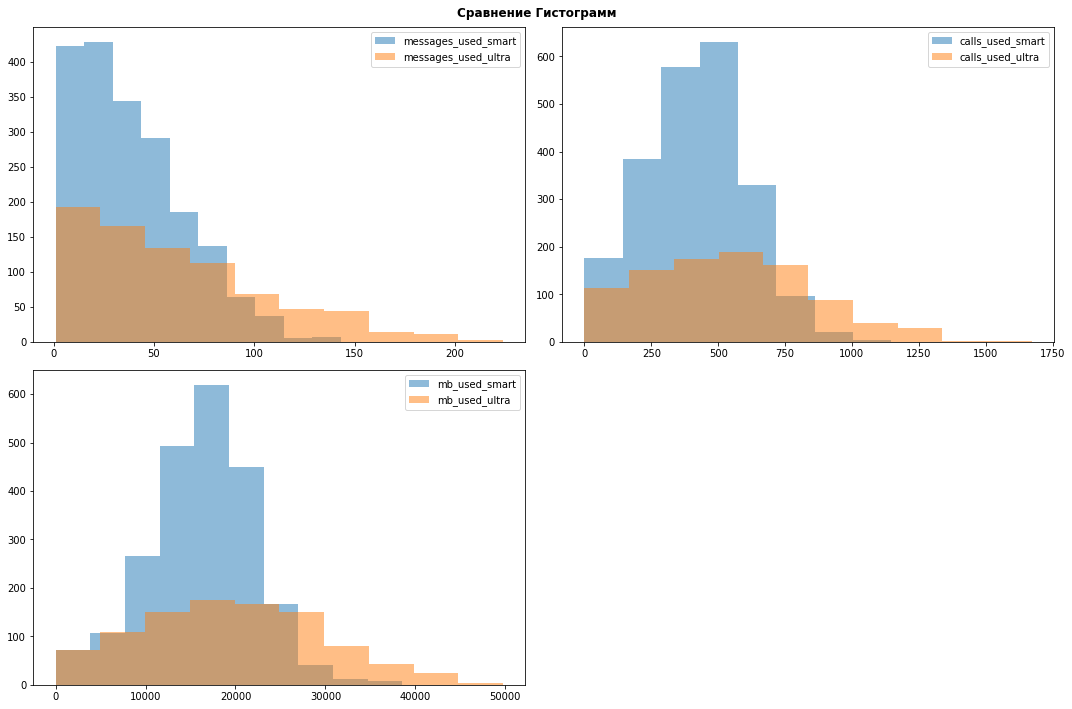

In [138]:
fig = plt.figure()

fig.set_figheight(10)
fig.set_figwidth(15)

plt.subplot(2, 2, 1)
plt.hist(df_smart['messages_used'], alpha=0.5, label='messages_used_smart')
plt.hist(df_ultra['messages_used'], alpha=0.5, label='messages_used_ultra')
plt.legend(loc='upper right')

plt.subplot(2, 2, 2)
plt.hist(df_smart['calls_used'], alpha=0.5, label='calls_used_smart')
plt.hist(df_ultra['calls_used'], alpha=0.5, label='calls_used_ultra')
plt.legend(loc='upper right')


plt.subplot(2, 2, 3)
plt.hist(df_smart['mb_used'], alpha=0.5, label='mb_used_smart')
plt.hist(df_ultra['mb_used'], alpha=0.5, label='mb_used_ultra')
plt.legend(loc='upper right')

plt.suptitle('Сравнение Гистограмм', fontweight='bold')

plt.tight_layout()

plt.show()

⚡**Вывод:**
1. Для двух гистограмм **по количеству использованных сообщений**, мы наблюдаем скошенность вправо. Также поведение данных одинаковая для двух гистограмм.

    - Гистограмма с дополнительными значениями справа отображает частоту значений в скошенном вправо наборе данных. Его также называют датасетом с положительной скошенностью, ведь дополнительные значения находятся со стороны положительного направления оси.
    - Помня о том, что медиана в отличие от среднего устойчива к выбросам, легко сделать вывод, что для скошенных вправо данных медиана будет меньше среднего, а для скошенных влево — больше.
    - Среднее «поедет» в ту сторону, где есть дополнительные значения. Медиана тоже будет туда двигаться, но намного медленнее.
    - Самый простой способ определения скошенности датасета — сравнить среднее и медиану. Куда сдвинуто среднее по отношению к медиане — туда и скошен датасет.
    

2. В гистограмме для тарифа `ultra`  **по количеству использованных минут**, мы наблюдаем что пик достигает 600 минут, в то время для тарифа `smart` пиковое значение 500 минут. для тарифа `smart` 90% значений сосрелаточены до 750 минут, а для тарифа `ultra` это значение равно 1000 минут.


3. В гистограмме для тарифа `ultra`  **по объему использованного интернета-трафика**, мы наблюдаем что 40% пользователей используют больше 25000 МБ, а 90% пользователей тарифа `smart` используют до 25000 МБ.

<span><a href="#Содержание" data-toc-modified-id="Содержание"><span class="toc-item-num"></span>Содержание</a></span>

## Проверка гипотез

In [181]:
sample_1 = df_smart['total_fee']
sample_2 = df_ultra['total_fee']

alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу

results = st.ttest_ind(
    sample_1, 
    sample_2)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

p-значение: 1.553031575858775e-151
Отвергаем нулевую гипотезу


Для проверки гипотез использовал критерий p-значение меньше 0.5, так как это критический уровень статистической значимости если p-value окажется меньше него - отвергнем гипотезу. p-value - это вероятность получить наблюдаемый или еще более далекий от предполагаемого результат при условии, что нулевая гипотеза верна. Возвращая этот результат, метод scipy.stats.ttest_1samp() строит распределение со значением, полученным на выборке, и подсчитывает вероятность, что оно могло оказаться там или ещё дальше от центра колокола.

1. **Нулевая гипотеза:** средняя выручка пользователей тарифов «Ультра» и «Смарт» не различаются. 
2. **Альтернативная гипотеза:** средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются.

In [182]:
sample_1 = df_income[df_income['city'] == 'Москва']['total_fee']
sample_2 = df_income[df_income['city'] == 'Санкт-Петербург']['total_fee']

alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу

results = st.ttest_ind(
    sample_1, 
    sample_2)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

p-значение: 0.18717650493454907
Не получилось отвергнуть нулевую гипотезу


1. **Нулевая гипотеза:** средняя выручка пользователей из Москвы не отличается от выручки пользователей из Санкт-Петербурга. 
2. **Альтернативная гипотеза:** средняя выручка пользователей из Москвы отличается от выручки пользователей из Санкт-Петербурга.

In [183]:
sample_1 = df_income[df_income['city'] == 'Москва']['total_fee']
sample_2 = df_income[df_income['city'] == 'Ростов-на-Дону']['total_fee']

alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу

results = st.ttest_ind(
    sample_1, 
    sample_2)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

p-значение: 0.17539109402121703
Не получилось отвергнуть нулевую гипотезу


1. **Нулевая гипотеза:** средняя выручка пользователей из Москвы не отличается от выручки пользователей из Ростов-на-Дону. 
2. **Альтернативная гипотеза:** средняя выручка пользователей из Москвы отличается от выручки пользователей из Ростов-на-Дону.

In [184]:
sample_1 = df_income[df_income['city'] == 'Москва']['total_fee']
sample_2 = df_income[df_income['city'] == 'Новосибирск']['total_fee']

alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу

results = st.ttest_ind(
    sample_1, 
    sample_2)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

p-значение: 0.003829436812663561
Отвергаем нулевую гипотезу


1. **Нулевая гипотеза:** средняя выручка пользователей из Москвы не отличается от выручки пользователей из Новосибирска. 
2. **Альтернативная гипотеза:** средняя выручка пользователей из Москвы отличается от выручки пользователей из Новосибирска.

⚡**Вывод:**

- **Проверил гипотезы:** 
    1. средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются
    2. средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов
    
    
- **Не были отвергнуты 2 нулевых гипотез, остальные были отвергнуты:**
    1. Альтернативная гипотеза: средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются.
    2. Нулевая гипотеза: средняя выручка пользователей из Москвы не отличается от выручки пользователей из Санкт-Петербурга.
    3. Нулевая гипотеза: средняя выручка пользователей из Москвы не отличается от выручки пользователей из Ростов-на-Дону.
    4. Альтернативная гипотеза: средняя выручка пользователей из Москвы отличается от выручки пользователей из Новосибирска.

<span><a href="#Содержание" data-toc-modified-id="Содержание"><span class="toc-item-num"></span>Содержание</a></span>